In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import math
from scipy.optimize import curve_fit

In [28]:
# -------------------------------------------------------------------
# 1. Parameters and file paths
# -------------------------------------------------------------------

# File paths
SUPPLY_PLAN_FILE = "../data/CUL October 2025 Supply Plan.xlsx"
REQUESTS_FILE2 = "../data/Ride Requests_2025-11-11-part-2.csv"
REQUESTS_FILE1 = "../data/Ride Requests_2025-11-11-part-1.csv"
RIDES_FILE = "../data/rides.csv"

# Time window for estimating λ and μ
OCT_START = pd.Timestamp("2025-10-01")
OCT_END = pd.Timestamp("2025-11-01")  # exclusive upper bound

# Driver cost assumptions
HOURLY_WAGE_8H = 20.0  # $/hour for 8-hour shift drivers
HOURLY_WAGE_4H = 25.0  # $/hour for 4-hour shift drivers

# Range of servers (drivers) to evaluate
MIN_DRIVERS = 5
MAX_DRIVERS = 30

In [29]:
# -------------------------------------------------------------------
# 2. Load data
# -------------------------------------------------------------------

supply_plan = pd.read_excel(SUPPLY_PLAN_FILE)
requests1 = pd.read_csv(REQUESTS_FILE1)
requests2 = pd.read_csv(REQUESTS_FILE2)
request = pd.concat([requests1, requests2], ignore_index=True)
rides = pd.read_csv(RIDES_FILE)


In [30]:
# -------------------------------------------------------------------
# 3. Helpers
# -------------------------------------------------------------------
def weekday_sorter(df):
    weekday_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ]

    df["weekday"] = pd.Categorical(
        df["weekday"], categories=weekday_order, ordered=True
    )
    df = df.sort_values("weekday")
    return df


def parse_datetime_column(df, col_name):
    return pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)

In [31]:
# -------------------------------------------------------------------
# 4. Preprocess rides: parse timestamps and filter October 2025
# -------------------------------------------------------------------

# Parse pickup and dropoff times
rides["Actual Pickup Time"] = parse_datetime_column(rides, "Actual Pickup Time")
rides["Actual Dropoff Time"] = parse_datetime_column(rides, "Actual Dropoff Time")

# Keep only completed rides with valid pickup & dropoff times
completed_mask = (
    rides["Actual Pickup Time"].notna() & rides["Actual Dropoff Time"].notna()
)
rides_completed = rides.loc[completed_mask].copy()

# Filter to October 2025
oct_mask = (rides_completed["Actual Pickup Time"] >= OCT_START) & (
    rides_completed["Actual Pickup Time"] < OCT_END
)
rides_oct = rides_completed.loc[oct_mask].copy()

if rides_oct.empty:
    raise ValueError(
        "No completed rides found in October 2025 for estimation. Check data / date range."
    )

/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/2290462358.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)
/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/2290462358.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)


In [32]:
# -------------------------------------------------------------------
# 5. Estimate μ (service rate) by weekday × hour
# -------------------------------------------------------------------

# Extract weekday + hour from pickup time
rides_oct["weekday"] = rides_oct["Actual Pickup Time"].dt.day_name()
rides_oct["hour"] = rides_oct["Actual Pickup Time"].dt.hour

# Compute ride durations in hours
ride_durations_hours = (
    rides_oct["Actual Dropoff Time"] - rides_oct["Actual Pickup Time"]
).dt.total_seconds() / 3600.0

rides_oct["duration_hours"] = ride_durations_hours

# Keep only positive durations
rides_oct = rides_oct[rides_oct["duration_hours"] > 0].copy()

# Group by weekday × hour
mu_df = (
    rides_oct.groupby(["weekday", "hour"])["duration_hours"]
    .mean()
    .reset_index()
    .rename(columns={"duration_hours": "mean_service_time_hours"})
)

# Convert mean duration to μ (service rate per hour per driver)
mu_df["mu_per_hour"] = 1.0 / mu_df["mean_service_time_hours"]

# Sort weekdays properly
mu_df = weekday_sorter(mu_df)
mu_df.sort_values(by=["weekday", "hour"], inplace=True)

print("\nWeekday × hour model (μ):")
print(mu_df)


Weekday × hour model (μ):
   weekday  hour  mean_service_time_hours  mu_per_hour
10  Monday     0                 0.141838     7.050273
11  Monday     1                 0.131863     7.583643
12  Monday     2                 0.310366     3.222004
13  Monday     3                 0.141667     7.058824
14  Monday    18                 0.148035     6.755149
..     ...   ...                      ...          ...
35  Sunday    19                 0.137840     7.254814
36  Sunday    20                 0.143537     6.966825
37  Sunday    21                 0.159107     6.285073
38  Sunday    22                 0.143961     6.946349
39  Sunday    23                 0.139607     7.162960

[70 rows x 4 columns]


In [33]:
# -------------------------------------------------------------------
# 6. Extract staffing by weekday x hour from the CUL supply plan
# -------------------------------------------------------------------

# Ensure Date is datetime
supply_plan["Date"] = pd.to_datetime(supply_plan["Date"])

# Map CUL columns to hour-of-day (0-23)
hour_column_map = {
    "4p-5p": 16,
    "5p-6p": 17,
    "6p-7p": 18,
    "7p-8p": 19,
    "8p-9p": 20,
    "9p-10p": 21,
    "10p-11p": 22,
    "11p-12a": 23,
    "12a-1a": 0,
    "1a-2a": 1,
    "2a-3a": 2,
}

hour_cols = list(hour_column_map.keys())

# Melt to long format: one row per (date, hour-block)
supply_long = supply_plan.melt(
    id_vars=["Date"], value_vars=hour_cols, var_name="time_block", value_name="drivers"
)

# Remove rows without drivers info
supply_long = supply_long.dropna(subset=["drivers"])

# Add weekday and numeric hour
supply_long["weekday"] = supply_long["Date"].dt.day_name()
supply_long["hour"] = supply_long["time_block"].map(hour_column_map)

# Average staffing by weekday × hour over October
weekday_hour_staffing = (
    supply_long.groupby(["weekday", "hour"])["drivers"]
    .mean()
    .reset_index()
    .rename(columns={"drivers": "avg_drivers"})
)
weekday_hour_staffing["avg_drivers"] = weekday_hour_staffing["avg_drivers"].round(0)
weekday_hour_staffing = weekday_sorter(weekday_hour_staffing)
weekday_hour_staffing.sort_values(by=["weekday", "hour"], inplace=True)

print("\nAverage staffing per weekday × hour:")
print(weekday_hour_staffing)

# Also compute an overall "current_drivers" from the peak column (for the vertical line)
avg_peak_drivers = supply_plan["Drivers @ Peak"].mean()
current_drivers = int(round(avg_peak_drivers))
print(
    f"\nApproximate current number of drivers (avg peak over October): {current_drivers}"
)


Average staffing per weekday × hour:
   weekday  hour  avg_drivers
11  Monday     0         10.0
12  Monday     1          6.0
13  Monday     2          4.0
14  Monday    16          0.0
15  Monday    17          0.0
..     ...   ...          ...
39  Sunday    19          8.0
40  Sunday    20         14.0
41  Sunday    21         14.0
42  Sunday    22         14.0
43  Sunday    23         12.0

[77 rows x 3 columns]

Approximate current number of drivers (avg peak over October): 16


In [34]:
# -------------------------------------------------------------------
# 8. Estimate λ per weekday × hour (arrival rate per hour)
# -------------------------------------------------------------------

# Attach weekday & hour to each completed ride
rides_oct["weekday"] = rides_oct["Actual Pickup Time"].dt.day_name()
rides_oct["hour"] = rides_oct["Actual Pickup Time"].dt.hour

# Count rides per weekday × hour over the whole month
lambda_counts = (
    rides_oct.groupby(["weekday", "hour"])["Actual Pickup Time"]
    .count()
    .reset_index()
    .rename(columns={"Actual Pickup Time": "num_rides"})
)

# Number of occurrences of each weekday in the month (exposure time)
days_per_weekday = (
    supply_plan.assign(weekday=supply_plan["Date"].dt.day_name())
    .groupby("weekday")["Date"]
    .nunique()
    .reset_index()
    .rename(columns={"Date": "num_days"})
)

print(lambda_counts)

      weekday  hour  num_rides
0      Friday     0        306
1      Friday     1        210
2      Friday     2        187
3      Friday     3         14
4      Friday    18        256
..        ...   ...        ...
65  Wednesday    19        432
66  Wednesday    20        467
67  Wednesday    21        506
68  Wednesday    22        452
69  Wednesday    23        399

[70 rows x 3 columns]


In [35]:
# -------------------------------------------------------------------
# 8 bis. Estimate λ using 'Request Creation Time' column (to include not only completed rides)
# -------------------------------------------------------------------

# Parse 'Request Creation Time'
request["Request Creation Time"] = parse_datetime_column(
    request, "Request Creation Time"
)
# Filter to October 2025
oct_mask_req = (request["Request Creation Time"] >= OCT_START) & (
    request["Request Creation Time"] < OCT_END
)
request_oct = request.loc[oct_mask_req].copy()

# Convert 'Request Creation Time' to weekday and hour
request_oct["weekday"] = request_oct["Request Creation Time"].dt.day_name()
request_oct["hour"] = request_oct["Request Creation Time"].dt.hour
# Count requests per weekday × hour over the whole month
lambda_counts_req = (
    request_oct.groupby(["weekday", "hour"])["Request Creation Time"]
    .count()
    .reset_index()
    .rename(columns={"Request Creation Time": "num_requests"})
)
lambda_counts_req = weekday_sorter(lambda_counts_req)
print("\nRide requests counts per weekday × hour:")
print(lambda_counts_req)


Ride requests counts per weekday × hour:
   weekday  hour  num_requests
19  Monday    23           438
18  Monday    22           551
17  Monday    21           650
16  Monday    20           731
15  Monday    19           620
..     ...   ...           ...
35  Sunday    19           473
36  Sunday    20           589
37  Sunday    21           496
39  Sunday    23           405
34  Sunday    18           446

[70 rows x 3 columns]


/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/2290462358.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)


In [36]:
# -------------------------------------------------------------------
# 9. Combine staffing and arrival counts by weekday × hour
# -------------------------------------------------------------------
def combine_staffing_completed_rides(
    weekday_hour_staffing, lambda_counts, days_per_weekday, mu_df
):
    # Merge staffing (weekday, hour) with observed ride counts (weekday, hour)
    weekday_hour_model = weekday_hour_staffing.merge(
        lambda_counts, on=["weekday", "hour"], how="left"
    )

    # Merge in the number of days per weekday (for exposure)
    weekday_hour_model = weekday_hour_model.merge(
        days_per_weekday, on="weekday", how="left"
    )

    # If no rides observed for a (weekday, hour), set num_rides = 0
    weekday_hour_model["num_rides"] = weekday_hour_model["num_rides"].fillna(0)

    # Arrival rate per hour = total rides / number of days of that weekday
    weekday_hour_model["lambda_per_hour"] = (
        weekday_hour_model["num_rides"] / weekday_hour_model["num_days"]
    )

    # Merge with service rate μ
    weekday_hour_model = weekday_hour_model.merge(
        mu_df[["weekday", "hour", "mu_per_hour"]], on=["weekday", "hour"], how="left"
    )
    return weekday_hour_model


# Do all the above but for request data
def combine_staffing_requests(
    weekday_hour_staffing, lambda_counts_req, days_per_weekday, mu_df
):
    # Merge staffing (weekday, hour) with observed request counts (weekday, hour)
    weekday_hour_model_req = weekday_hour_staffing.merge(
        lambda_counts_req, on=["weekday", "hour"], how="left"
    )

    # Merge in the number of days per weekday (for exposure)
    weekday_hour_model_req = weekday_hour_model_req.merge(
        days_per_weekday, on="weekday", how="left"
    )

    # If no requests observed for a (weekday, hour), set num_requests = 0
    weekday_hour_model_req["num_requests"] = weekday_hour_model_req[
        "num_requests"
    ].fillna(0)

    # Arrival rate per hour = total requests / number of days of that weekday
    weekday_hour_model_req["lambda_per_hour"] = (
        weekday_hour_model_req["num_requests"] / weekday_hour_model_req["num_days"]
    )

    # Merge with service rate μ
    weekday_hour_model_req = weekday_hour_model_req.merge(
        mu_df[["weekday", "hour", "mu_per_hour"]], on=["weekday", "hour"], how="left"
    )

    return weekday_hour_model_req

In [37]:
weekday_hour_model = combine_staffing_completed_rides(
    weekday_hour_staffing, lambda_counts, days_per_weekday, mu_df
)
weekday_hour_model_req = combine_staffing_requests(
    weekday_hour_staffing, lambda_counts_req, days_per_weekday, mu_df
)

## M/M/m Queueing Model

We model the shuttle system as an **M/M/m queue**, where:

- arrivals follow a Poisson process with rate \( \lambda \),
- service times are exponential with rate \( \mu \),
- \( m \) servers (drivers) operate in parallel,
- passengers wait in a FIFO queue with no abandonment for simplicity.

---

### Utilization

$$
\rho = \frac{\lambda}{m \mu}
$$

The system is **stable** only if:

$$
\rho < 1
$$

---

### Probability of Zero Customers

The normalizing constant \( P_0 \) is:

$$
P_0 =
\left(
\sum_{k=0}^{m-1} \frac{(m\rho)^k}{k!}
+
\frac{(m\rho)^m}{m! (1-\rho)}
\right)^{-1}
$$

---

### Erlang-C Waiting Probability

$$
P(\text{wait}) =
\frac{(m\rho)^m}{m! (1-\rho)} \, P_0
$$

---

### Average Queue Length

$$
L_q = P(\text{wait}) \cdot \frac{\rho}{1-\rho}
$$

---

### Average Waiting Time in Queue

$$
W_q = \frac{L_q}{\lambda}
$$

---

### Average Time in System

$$
W = W_q + \frac{1}{\mu}
$$

---

This model provides the expected waiting and total time per passenger for a given hour, given:

- $ \lambda $ (demand),
- $ \mu $ (service rate per driver),
- m (number of available drivers).


In [38]:
# -------------------------------------------------------------------
# 10. M/M/m performance formulas and simulation with extra drivers
# -------------------------------------------------------------------


def mm_m_waiting_time(lambda_rate, mu_rate, m):
    """
    Compute Wq (average waiting time in queue) and W (total sojourn time)
    for an M/M/m system, using the standard Erlang-C formula.

    Parameters
    ----------
    lambda_rate : float
        Arrival rate (per day x hour).
    mu_rate : float
        Service rate per server (per day x hour).
    m : int
        Number of servers.

    Returns
    -------
    Wq : float
        Average waiting time in queue (in hours). np.nan if system is unstable.
    W : float
        Average time in the system (waiting + service) in hours.
    """

    # No arrivals: no queue, only service time
    if lambda_rate <= 0:
        Wq = 0.0
        W = 1.0 / mu_rate
        return Wq, W

    # Utilization ρ
    rho = lambda_rate / (m * mu_rate)

    # If ρ ≥ 1, the system is unstable
    if rho >= 1.0:
        return np.nan, np.nan

    # mρ = λ/μ
    m_rho = m * rho

    # Compute P0 (probability of zero customers in the system)
    sum_terms = 0.0
    for k in range(m):
        sum_terms += (m_rho**k) / math.factorial(k)

    # Last term represents the geometric tail (states n ≥ m)
    last_term = (m_rho**m) / (math.factorial(m) * (1 - rho))

    denominator = sum_terms + last_term
    P0 = 1.0 / denominator

    # Erlang-C: probability that an arriving customer must wait
    P_wait = last_term * P0

    # Average number in queue (closed form)
    Lq = P_wait * (rho / (1 - rho))

    # Average waiting time in queue
    Wq = Lq / lambda_rate

    # Total time in system (waiting + service)
    W = Wq + 1.0 / mu_rate

    return Wq, W


def simul_waittimes_m(day, hour, M):
    """
    Returns a list of average waiting times in minutes for an M/M/m system for a given day and hour, varying the number of drivers from base_drivers to base_drivers + max_extra.
    Parameters
    ----------
    day : str
        Day of the week (e.g., "Monday").
    hour : int
        Hour of the day (0-23).
    base_drivers : int
        Base number of drivers.
    max_extra : int
        Maximum number of extra drivers to simulate.
    Returns
    -------
    list of float
        Average waiting times in minutes for each number of drivers from
        base_drivers to base_drivers + max_extra.
    """
    row = weekday_hour_model[
        (weekday_hour_model["weekday"] == day) & (weekday_hour_model["hour"] == hour)
    ].iloc[0]

    lam = row["lambda_per_hour"]
    mu = row["mu_per_hour"]
    results = []
    for m in range(M):
        Wq, W = mm_m_waiting_time(lam, mu, m)

        if Wq is None or math.isnan(Wq):
            results.append(None)
        else:
            results.append(round(Wq * 60, 2))

    return results


def simul_waittimes_m_req(day, hour, M):
    """
    Returns a list of average waiting times in minutes for an M/M/m system for a given day and hour, varying the number of drivers from base_drivers to base_drivers + max_extra.
    Parameters
    ----------
    day : str
        Day of the week (e.g., "Monday").
    hour : int
        Hour of the day (0-23).
    base_drivers : int
        Base number of drivers.
    M : int
        Maximum number of extra drivers to simulate.
    Returns
    -------
    list of float
        Average waiting times in minutes for each number of drivers from
        base_drivers to base_drivers + max_extra.
    """
    row = weekday_hour_model_req[
        (weekday_hour_model_req["weekday"] == day)
        & (weekday_hour_model_req["hour"] == hour)
    ].iloc[0]

    lam = row["lambda_per_hour"]
    mu = row["mu_per_hour"]
    results = []
    for m in range(M):
        Wq, W = mm_m_waiting_time(lam, mu, m)

        if Wq is None or math.isnan(Wq):
            results.append(None)
        else:
            results.append(round(Wq * 60, 2))

    return results

## Focus on peak hours

In [39]:
days = weekday_hour_model["weekday"].unique()
hours = sorted(weekday_hour_model["hour"].unique())
max_extra = 10

wait_time_data_all = {}

hours_peak = [18, 19, 20, 21, 22, 23, 0, 1, 2]

### Completed rides

/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/1250262357.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  rho = lambda_rate / (m * mu_rate)


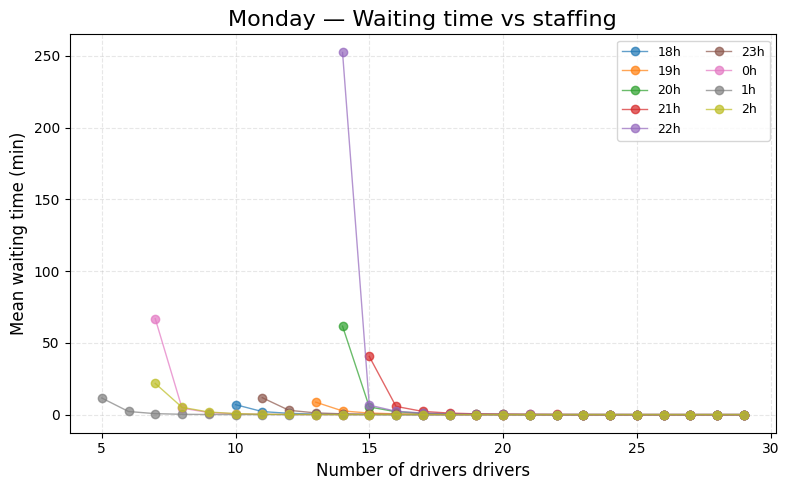

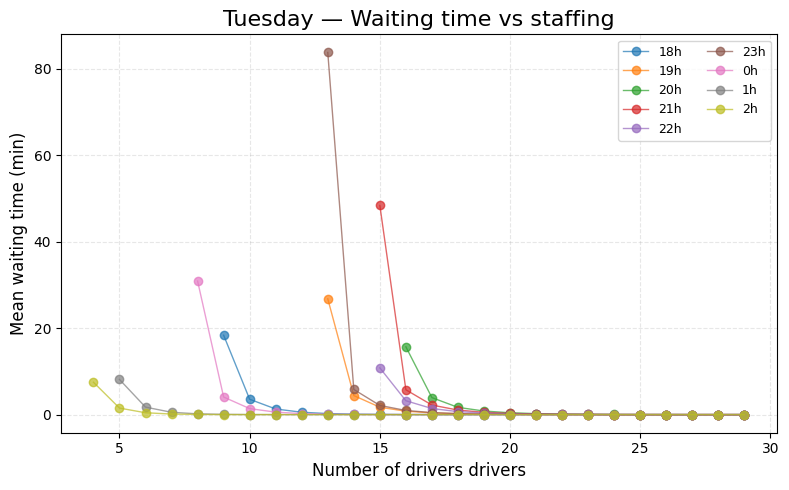

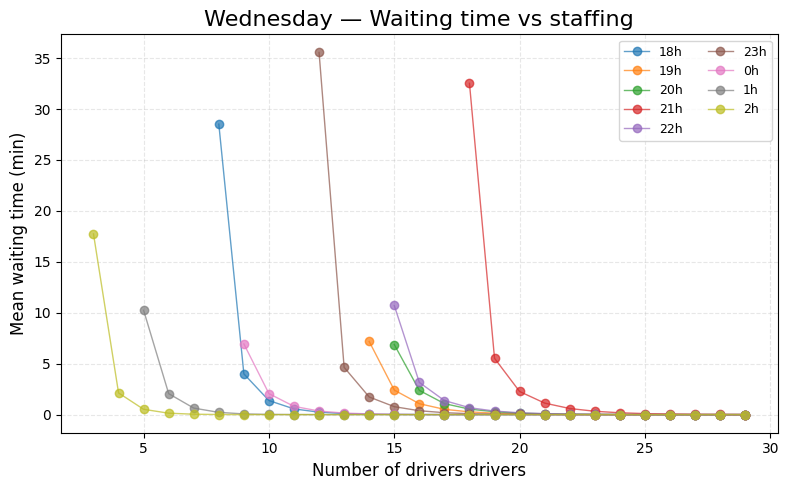

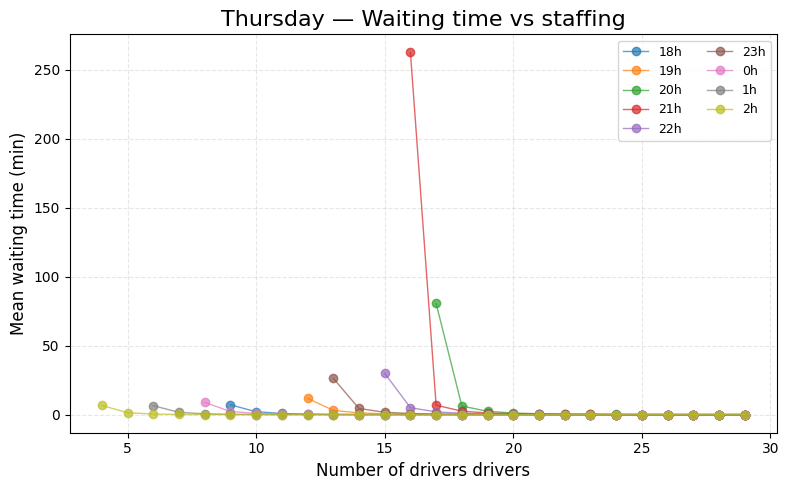

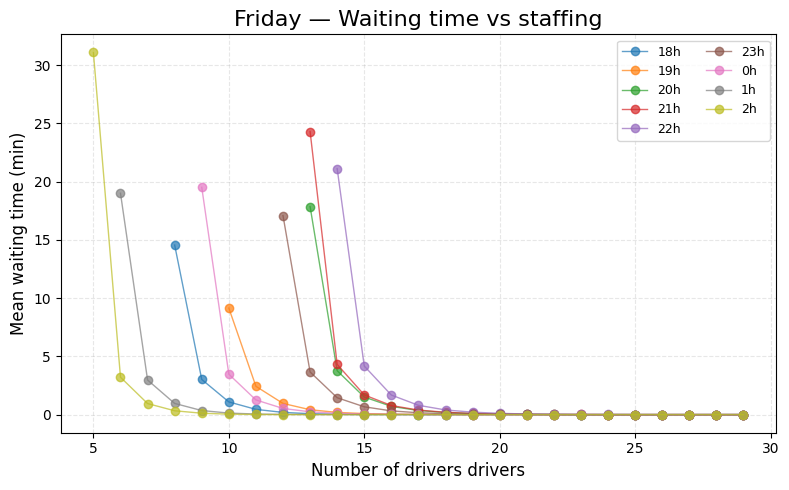

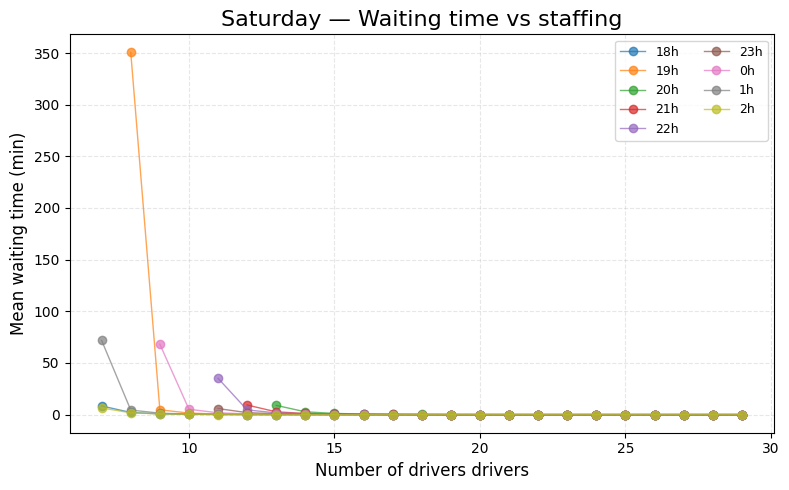

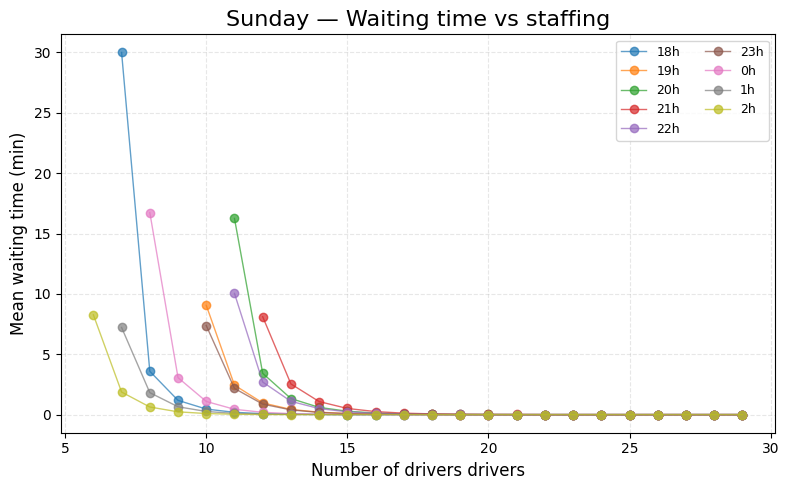

In [40]:
for day in days:
    wait_time_data_all[day] = {}
    for hour in hours_peak:
        wait_time_data_all[day][hour] = simul_waittimes_m(day, hour, 30)

for day in days:
    plt.figure(figsize=(8, 5))

    # ---- plot waiting time curves ----
    for hour in hours_peak:
        waits = wait_time_data_all[day][hour]
        x = list(range(len(waits)))
        plt.plot(x, waits, marker="o", linewidth=1, alpha=0.7, label=f"{hour}h")

    plt.xlabel("Number of drivers drivers", fontsize=12)
    plt.ylabel("Mean waiting time (min)", fontsize=12)
    plt.title(f"{day} — Waiting time vs staffing", fontsize=16)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

In [41]:
# For each hour for each day, min number of drivers so model is stable (ρ < 1)
stable_drivers = {}
for day in days:
    stable_drivers[day] = {}
    for hour in hours_peak:
        row = weekday_hour_model[
            (weekday_hour_model["weekday"] == day)
            & (weekday_hour_model["hour"] == hour)
        ].iloc[0]

        lam = row["lambda_per_hour"]
        mu = row["mu_per_hour"]

        # Minimum m so that ρ < 1
        min_m = math.ceil(lam / mu)
        stable_drivers[day][hour] = min_m

print("\nMinimum number of drivers for system stability (ρ < 1):")
for day in days:
    print(f"{day}:")
    for hour in hours_peak:
        print(f"  {hour}h: {stable_drivers[day][hour]} drivers")


Minimum number of drivers for system stability (ρ < 1):
Monday:
  18h: 10 drivers
  19h: 13 drivers
  20h: 14 drivers
  21h: 15 drivers
  22h: 14 drivers
  23h: 11 drivers
  0h: 7 drivers
  1h: 5 drivers
  2h: 7 drivers
Tuesday:
  18h: 9 drivers
  19h: 13 drivers
  20h: 16 drivers
  21h: 15 drivers
  22h: 15 drivers
  23h: 13 drivers
  0h: 8 drivers
  1h: 5 drivers
  2h: 4 drivers
Wednesday:
  18h: 8 drivers
  19h: 14 drivers
  20h: 15 drivers
  21h: 18 drivers
  22h: 15 drivers
  23h: 12 drivers
  0h: 9 drivers
  1h: 5 drivers
  2h: 3 drivers
Thursday:
  18h: 9 drivers
  19h: 12 drivers
  20h: 17 drivers
  21h: 16 drivers
  22h: 15 drivers
  23h: 13 drivers
  0h: 8 drivers
  1h: 6 drivers
  2h: 4 drivers
Friday:
  18h: 8 drivers
  19h: 10 drivers
  20h: 13 drivers
  21h: 13 drivers
  22h: 14 drivers
  23h: 12 drivers
  0h: 9 drivers
  1h: 6 drivers
  2h: 5 drivers
Saturday:
  18h: 7 drivers
  19h: 8 drivers
  20h: 13 drivers
  21h: 12 drivers
  22h: 11 drivers
  23h: 10 drivers
  0h:

In [42]:
# Min number of drivers for stability across all hours
overall_stable_drivers = {}
for day in days:
    overall_stable_drivers[day] = max(stable_drivers[day].values())
print(
    "\nOverall minimum number of drivers for stability across all operationnal hours:"
)
for day in days:
    print(f"{day}: {overall_stable_drivers[day]} drivers")


Overall minimum number of drivers for stability across all operationnal hours:
Monday: 15 drivers
Tuesday: 16 drivers
Wednesday: 18 drivers
Thursday: 17 drivers
Friday: 14 drivers
Saturday: 13 drivers
Sunday: 12 drivers


In [43]:
# Min number of drivers to get Wq < 5 minutes day by day and hour by hour
min_drivers_Wq5 = {}
for day in days:
    min_drivers_Wq5[day] = {}
    for hour in hours_peak:
        waits = wait_time_data_all[day][hour]

        min_drivers = None
        for m, Wq in enumerate(waits):
            if Wq is not None and Wq < 5.0:
                min_drivers = m
                break

        min_drivers_Wq5[day][hour] = min_drivers
print("\nMinimum number of drivers for Wq < 5 minutes:")
for day in days:
    print(f"{day}:")
    for hour in hours_peak:
        print(f"  {hour}h: {min_drivers_Wq5[day][hour]} drivers")


Minimum number of drivers for Wq < 5 minutes:
Monday:
  18h: 11 drivers
  19h: 14 drivers
  20h: 16 drivers
  21h: 17 drivers
  22h: 16 drivers
  23h: 12 drivers
  0h: 8 drivers
  1h: 6 drivers
  2h: 9 drivers
Tuesday:
  18h: 10 drivers
  19h: 14 drivers
  20h: 17 drivers
  21h: 17 drivers
  22h: 16 drivers
  23h: 15 drivers
  0h: 9 drivers
  1h: 6 drivers
  2h: 5 drivers
Wednesday:
  18h: 9 drivers
  19h: 15 drivers
  20h: 16 drivers
  21h: 20 drivers
  22h: 16 drivers
  23h: 13 drivers
  0h: 10 drivers
  1h: 6 drivers
  2h: 4 drivers
Thursday:
  18h: 10 drivers
  19h: 13 drivers
  20h: 19 drivers
  21h: 18 drivers
  22h: 17 drivers
  23h: 14 drivers
  0h: 9 drivers
  1h: 7 drivers
  2h: 5 drivers
Friday:
  18h: 9 drivers
  19h: 11 drivers
  20h: 14 drivers
  21h: 14 drivers
  22h: 15 drivers
  23h: 13 drivers
  0h: 10 drivers
  1h: 7 drivers
  2h: 6 drivers
Saturday:
  18h: 8 drivers
  19h: 9 drivers
  20h: 14 drivers
  21h: 13 drivers
  22h: 12 drivers
  23h: 12 drivers
  0h: 11 dr

In [44]:
# Min number of drivers to get Wq < 5 minutes across all hours
overall_min_drivers_Wq5 = {}
for day in days:
    drivers_needed = [
        min_drivers_Wq5[day][hour]
        for hour in hours_peak
        if min_drivers_Wq5[day][hour] is not None
    ]
    if drivers_needed:
        overall_min_drivers_Wq5[day] = max(drivers_needed)
    else:
        overall_min_drivers_Wq5[day] = None
print(
    "\nOverall minimum number of drivers for Wq < 5 minutes across all operationnal hours:"
)
for day in days:
    print(f"{day}: {overall_min_drivers_Wq5[day]} drivers")


Overall minimum number of drivers for Wq < 5 minutes across all operationnal hours:
Monday: 17 drivers
Tuesday: 17 drivers
Wednesday: 20 drivers
Thursday: 19 drivers
Friday: 15 drivers
Saturday: 14 drivers
Sunday: 13 drivers


### Graphs using all the rides (requested)

/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/1250262357.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  rho = lambda_rate / (m * mu_rate)


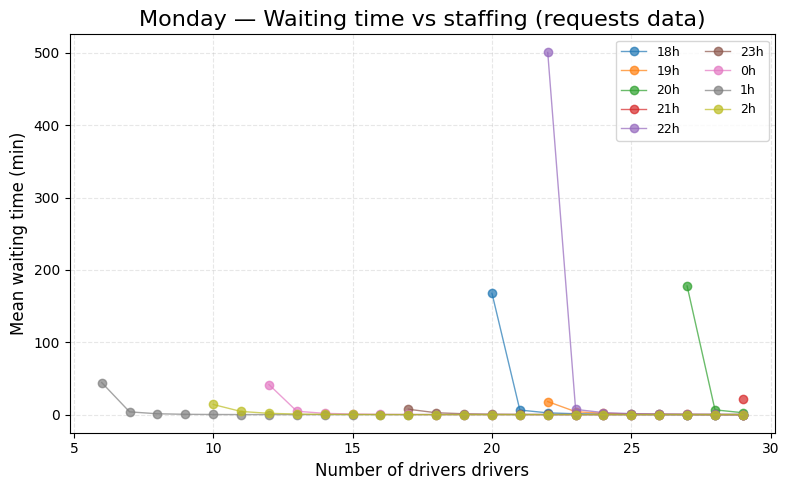

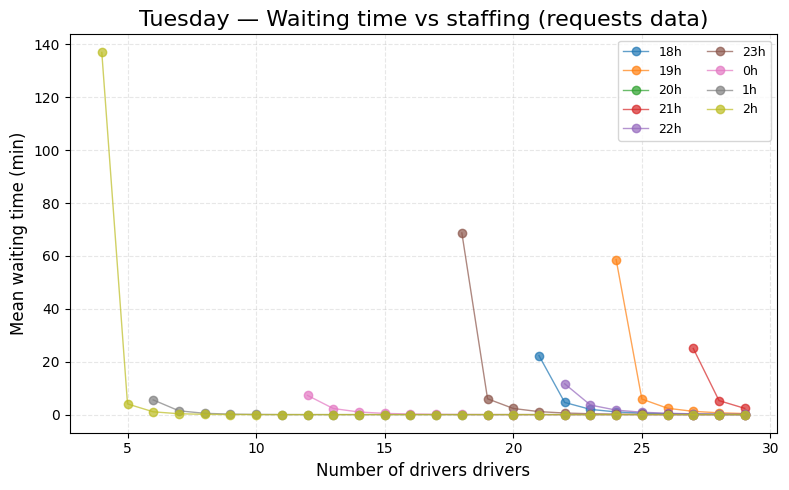

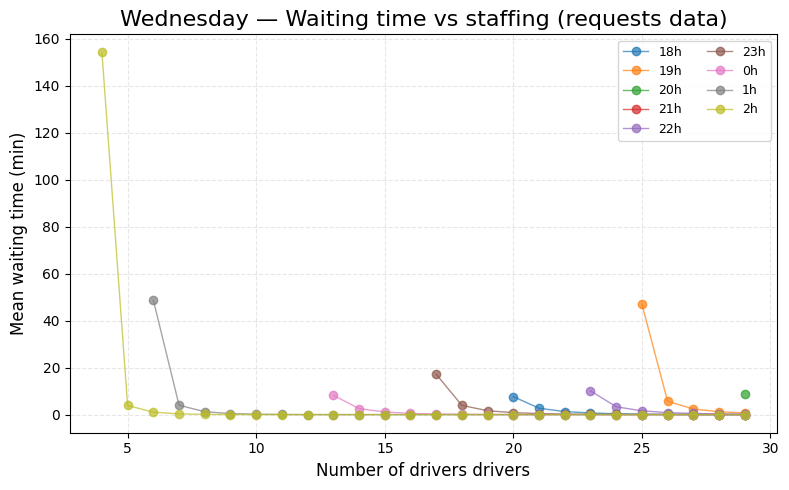

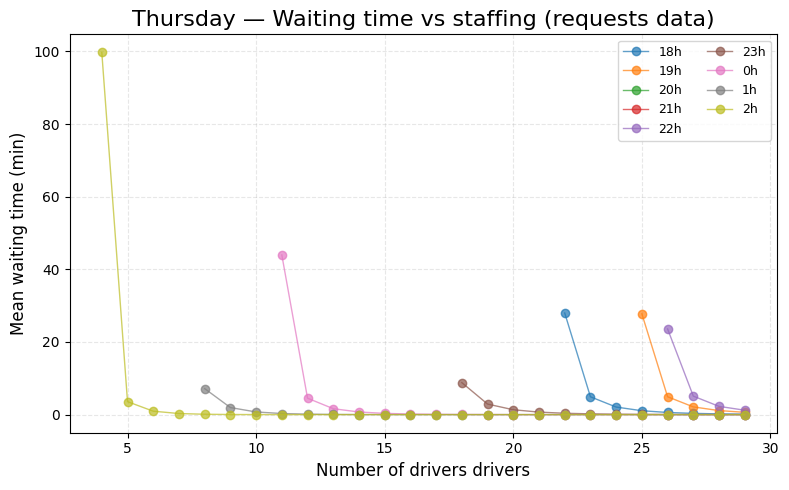

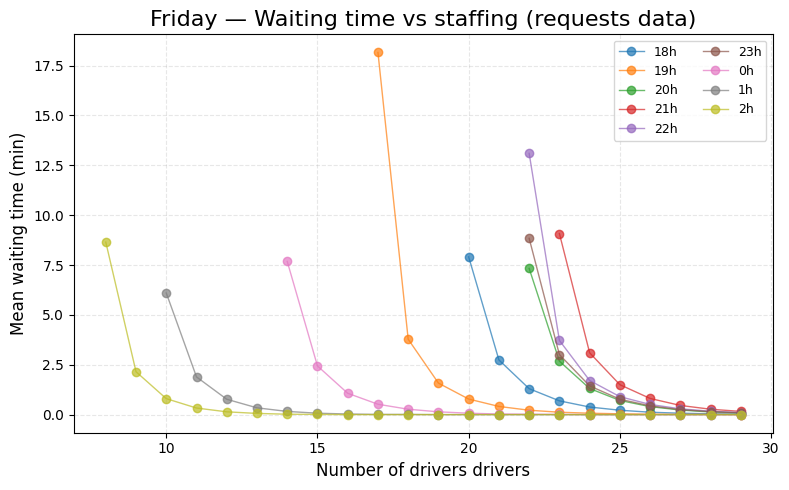

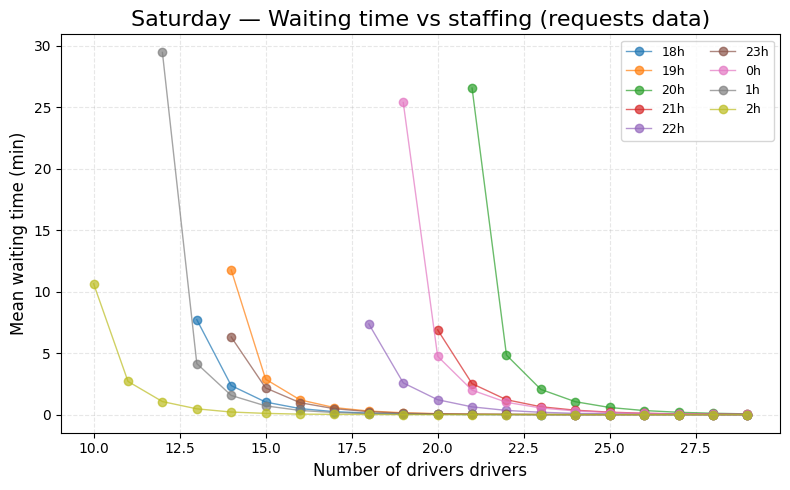

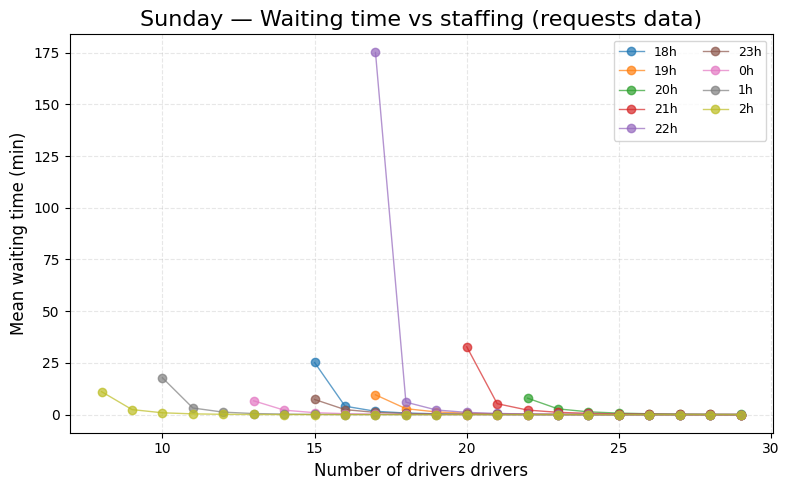

In [45]:
# For requests data
wait_time_data_all_req = {}
for day in days:
    wait_time_data_all_req[day] = {}
    for hour in hours_peak:
        wait_time_data_all_req[day][hour] = simul_waittimes_m_req(day, hour, 30)

for day in days:
    plt.figure(figsize=(8, 5))

    for hour in hours_peak:
        waits = wait_time_data_all_req[day][hour]
        x = list(range(len(waits)))
        plt.plot(x, waits, marker="o", linewidth=1, alpha=0.7, label=f"{hour}h")

    plt.xlabel("Number of drivers drivers", fontsize=12)
    plt.ylabel("Mean waiting time (min)", fontsize=12)
    plt.title(f"{day} — Waiting time vs staffing (requests data)", fontsize=16)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend(ncol=2, fontsize=9)

    plt.tight_layout()
    plt.show()

In [46]:
# Min number of drivers for stability across all hours (requests data)
overall_stable_drivers_req = {}
for day in days:
    overall_stable_drivers_req[day] = max(stable_drivers[day].values())
print(
    "\nOverall minimum number of drivers for stability across all operationnal hours (requests data):"
)
for day in days:
    print(f"{day}: {overall_stable_drivers_req[day]} drivers")



Overall minimum number of drivers for stability across all operationnal hours (requests data):
Monday: 15 drivers
Tuesday: 16 drivers
Wednesday: 18 drivers
Thursday: 17 drivers
Friday: 14 drivers
Saturday: 13 drivers
Sunday: 12 drivers


In [47]:
# For requests data: Min number of drivers to get Wq < 5 minutes day by day and hour by hour
min_drivers_Wq5_req = {}
for day in days:
    min_drivers_Wq5_req[day] = {}
    for hour in hours_peak:
        waits = wait_time_data_all_req[day][hour]

        min_drivers = None
        for m, Wq in enumerate(waits):
            if Wq is not None and Wq < 5.0:
                min_drivers = m
                break

        min_drivers_Wq5_req[day][hour] = min_drivers
print("\n(Requests data) Minimum number of drivers for Wq < 5 minutes:")
for day in days:
    print(f"{day}:")
    for hour in hours_peak:
        print(f"  {hour}h: {min_drivers_Wq5_req[day][hour]} drivers")


(Requests data) Minimum number of drivers for Wq < 5 minutes:
Monday:
  18h: 22 drivers
  19h: 23 drivers
  20h: 29 drivers
  21h: None drivers
  22h: 24 drivers
  23h: 18 drivers
  0h: 13 drivers
  1h: 7 drivers
  2h: 11 drivers
Tuesday:
  18h: 22 drivers
  19h: 26 drivers
  20h: None drivers
  21h: 29 drivers
  22h: 23 drivers
  23h: 20 drivers
  0h: 13 drivers
  1h: 7 drivers
  2h: 5 drivers
Wednesday:
  18h: 21 drivers
  19h: 27 drivers
  20h: None drivers
  21h: None drivers
  22h: 24 drivers
  23h: 18 drivers
  0h: 14 drivers
  1h: 7 drivers
  2h: 5 drivers
Thursday:
  18h: 23 drivers
  19h: 26 drivers
  20h: None drivers
  21h: None drivers
  22h: 28 drivers
  23h: 19 drivers
  0h: 12 drivers
  1h: 9 drivers
  2h: 5 drivers
Friday:
  18h: 21 drivers
  19h: 18 drivers
  20h: 23 drivers
  21h: 24 drivers
  22h: 23 drivers
  23h: 23 drivers
  0h: 15 drivers
  1h: 11 drivers
  2h: 9 drivers
Saturday:
  18h: 14 drivers
  19h: 15 drivers
  20h: 22 drivers
  21h: 21 drivers
  22h: 19 

In [48]:
# Min number of drivers to get Wq < 5 minutes across all hours
overall_min_drivers_Wq5_req = {}
for day in days:
    drivers_needed = [
        min_drivers_Wq5_req[day][hour]
        for hour in hours_peak
        if min_drivers_Wq5_req[day][hour] is not None
    ]
    if drivers_needed:
        overall_min_drivers_Wq5_req[day] = max(drivers_needed)
    else:
        overall_min_drivers_Wq5_req[day] = None
print(
    "\n(Requests data) Overall minimum number of drivers for Wq < 5 minutes across all operationnal hours:"
)
for day in days:
    print(f"{day}: {overall_min_drivers_Wq5_req[day]} drivers")



(Requests data) Overall minimum number of drivers for Wq < 5 minutes across all operationnal hours:
Monday: 29 drivers
Tuesday: 29 drivers
Wednesday: 27 drivers
Thursday: 28 drivers
Friday: 24 drivers
Saturday: 22 drivers
Sunday: 23 drivers


## Schedule from 18:00 to 22:59 by hour from 10/06 to 10/12

In [49]:
# Data from Oct 6th to Oct 12th
oct_6_12 = rides_completed[
    (rides_completed["Actual Pickup Time"] >= pd.Timestamp("2025-10-06"))
    & (rides_completed["Actual Pickup Time"] < pd.Timestamp("2025-10-13"))
].copy()


oct_6_12["Request Creation Time"] = parse_datetime_column(
    oct_6_12, "Request Creation Time"
)

oct_6_12["date"] = oct_6_12["Request Creation Time"].dt.date  # <-- vraie date
oct_6_12["weekday"] = oct_6_12["Request Creation Time"].dt.day_name()
oct_6_12["hour"] = oct_6_12["Request Creation Time"].dt.hour

oct_6_12_peak = oct_6_12[(oct_6_12["hour"] >= 18) & (oct_6_12["hour"] <= 23)].copy()

oct_6_12_peak_counts = (
    oct_6_12_peak.groupby(["date", "weekday", "hour"])["Request Creation Time"]
    .count()
    .reset_index()
    .rename(columns={"Request Creation Time": "num_requests"})
)

oct_6_12_peak_counts

/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/2290462358.py:23: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(df[col_name], errors="coerce", infer_datetime_format=True)


,date,weekday,hour,num_requests
0,2025-10-05,Sunday,23,21
1,2025-10-06,Monday,18,70
2,2025-10-06,Monday,19,97
3,2025-10-06,Monday,20,108
4,2025-10-06,Monday,21,78
5,2025-10-06,Monday,22,64
6,2025-10-06,Monday,23,72
7,2025-10-07,Tuesday,18,76
8,2025-10-07,Tuesday,19,112
9,2025-10-07,Tuesday,20,105


In [50]:
def exp_model(x, a, b, c):
    return a * np.exp(-b * x) + c


def fit_exp_curve(x_data, y_data):
    x = np.array(x_data, dtype=float)
    y = np.array(y_data, dtype=float)

    p0 = [max(y), 0.1, min(y)]
    params, _ = curve_fit(exp_model, x, y, p0=p0, maxfev=20000)
    return params  # a, b, c


def compute_x_beta(a, b, c, beta=0.05):
    if b <= 0 or c <= 0:
        return None

    numerator = a * (np.exp(b * (1 - beta)) - 1)
    denominator = beta * c

    if numerator <= 0 or denominator <= 0:
        return None

    arg = numerator / denominator
    if arg <= 0:
        return None

    x_beta = (1 / b) * np.log(arg)

    return math.ceil(x_beta)

In [51]:
df = oct_6_12_peak_counts.copy()

base_drivers = 1
max_extra = 30
driver_range = list(range(base_drivers, base_drivers + max_extra + 1))

rows = []

for (weekday, hour), sub in df.groupby(["weekday", "hour"]):
    lam = float(sub["num_requests"].mean())

    date = sub["date"].iloc[0]

    waittimes = []
    xvals = []

    for m in driver_range:
        wt_list = simul_waittimes_m_req(weekday, hour, m)
        Wq_m = wt_list[m - 1]

        if (Wq_m is None) or (isinstance(Wq_m, float) and np.isnan(Wq_m)):
            continue
        if np.isinf(Wq_m):
            continue

        waittimes.append(float(Wq_m))
        xvals.append(m)

    if len(waittimes) < 3:
        continue

    a, b, c = fit_exp_curve(xvals, waittimes)
    x_beta_05 = compute_x_beta(a, b, c, beta=0.05)
    x_beta_10 = compute_x_beta(a, b, c, beta=0.10)

    rows.append(
        {
            "date": date,
            "weekday": weekday,
            "hour": hour,
            "lambda": lam,
            "drivers_full": driver_range,
            "xvals": xvals,
            "waittimes": waittimes,
            "a": a,
            "b": b,
            "c": c,
            "x_beta_05": x_beta_05,
            "x_beta_10": x_beta_10,
        }
    )

fit_df = pd.DataFrame(rows)
fit_df["date"] = pd.to_datetime(fit_df["date"])
fit_df = fit_df.sort_values(by=["date", "hour"]).reset_index(drop=True)
fit_df.rename(columns={"xvals": "m (drivers)"}, inplace=True)
fit_df.drop(columns=["drivers_full"], inplace=True)
fit_df.to_csv("../data/wait_time_fits_oct6_12_requests.csv", index=False)
fit_df

/var/folders/j5/g36rlrm17vv157kr1c8_ndyw0000gn/T/ipykernel_63179/1250262357.py:35: RuntimeWarning: divide by zero encountered in scalar divide
  rho = lambda_rate / (m * mu_rate)


,date,weekday,hour,lambda,m (drivers),waittimes,a,b,c,x_beta_05,x_beta_10
0,2025-10-05,Sunday,23,28.0,"[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 2...","[7.33, 2.41, 1.08, 0.54, 0.28, 0.14, 0.08, 0.0...",1.304192e+08,1.044131,0.046939,25,24
1,2025-10-06,Monday,18,70.0,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]","[167.64, 6.32, 2.42, 1.19, 0.64, 0.36, 0.21, 0...",4.941024e+32,3.341030,0.525922,25,25
2,2025-10-06,Monday,19,97.0,"[23, 24, 25, 26, 27, 28, 29, 30, 31]","[18.04, 4.04, 1.78, 0.92, 0.52, 0.3, 0.17, 0.1...",1.228201e+16,1.485900,0.345203,29,28
3,2025-10-06,Monday,20,108.0,"[28, 29, 30, 31]","[177.69, 6.58, 2.62, 1.35]",1.874832e+46,3.620649,1.905395,32,31
4,2025-10-06,Monday,22,64.0,"[23, 24, 25, 26, 27, 28, 29, 30, 31]","[500.55, 7.2, 2.75, 1.37, 0.75, 0.43, 0.25, 0....",1.464484e+46,4.351579,0.808294,27,26
5,2025-10-06,Monday,23,72.0,"[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 2...","[7.42, 2.55, 1.18, 0.6, 0.32, 0.17, 0.09, 0.05...",4.987236e+08,1.002097,0.062366,27,26
6,2025-10-07,Tuesday,18,76.0,"[22, 23, 24, 25, 26, 27, 28, 29, 30, 31]","[22.31, 4.59, 1.98, 1.02, 0.56, 0.32, 0.18, 0....",1.843960e+16,1.562068,0.342292,28,27
7,2025-10-07,Tuesday,19,112.0,"[25, 26, 27, 28, 29, 30, 31]","[58.6, 5.88, 2.4, 1.23, 0.69, 0.4, 0.24]",6.731245e+27,2.400823,0.848949,29,29
8,2025-10-07,Tuesday,21,94.0,"[28, 29, 30, 31]","[25.0, 5.29, 2.36, 1.26]",9.305375e+22,1.775909,1.375153,33,32
9,2025-10-07,Tuesday,22,89.0,"[23, 24, 25, 26, 27, 28, 29, 30, 31]","[11.64, 3.62, 1.7, 0.9, 0.51, 0.29, 0.17, 0.1,...",2.519107e+12,1.135956,0.254801,30,29
